# **Homework 5 - Sequence-to-sequence**

若有任何问题，欢迎来信至助教信箱 ntu-ml-2021spring-ta@googlegroups.com

### (4/21 Updates)
1. Link to reference [training curves](https://wandb.ai/george0828zhang/hw5.seq2seq.new).

### (4/14 Updates) 
1. Link to tutorial [video](https://youtu.be/htG5WpZVQPU).
2. Now defaults to load `"avg_last_5_checkpoint.pt"` to generate prediction.
3. Expected run time on Colab with Tesla T4

|Baseline|Details|Total Time|
|-|:-:|:-:|
|Simple|2m 15s $\times$30 epochs|1hr 8m|
|Medium|4m $\times$30 epochs|2hr|
|Strong|8m $\times$30 epochs (backward)<br>+1hr (back-translation)<br>+15m $\times$30 epochs (forward)|12hr 30m|

# Sequence-to-Sequence 介绍
- 大多数常见的 seq2seq model 为 encoder-decoder model，主要由两个部分组成，分别是 encoder 和 decoder，而这两个部可以使用 recurrent neural network (RNN)或 transformer 来实作，主要是用来解决输入和输出的长度不一样的情况
- **Encoder** 是将一连串的输入，如文字、影片、声音讯号等，编码为单个向量，这单个向量可以想像为是整个输入的抽象表示，包含了整个输入的资讯
- **Decoder** 是将 encoder 输出的单个向量逐步解码，一次输出一个结果，直到将最后目标输出被产生出来为止，每次输出会影响下一次的输出，一般会在开头加入 "< BOS >" 来表示开始解码，会在结尾输出 "< EOS >" 来表示输出结束


![seq2seq](https://i.imgur.com/0zeDyuI.png)

# 作业介绍
- 英文翻译中文
  - 输入： 一句英文 （e.g.		tom is a student .） 
  - 输出： 中文翻译 （e.g. 		汤姆 是 个 学生 。）

- TODO
  - 训练一个 RNN 模型达到 Seq2seq 翻译
  - 训练一个 Transformer 大幅提升效能
  - 实作 Back-translation 大幅提升效能

# 下载和引入需要的函式库

In [1]:
# !pip install torch matplotlib sacrebleu sentencepiece tqdm wandb ipywidgets

In [2]:
import sys
import pprint
import logging
import os
import random
import re
import shutil
from copy import deepcopy
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm.auto import tqdm
from pathlib import Path
from argparse import Namespace
import sentencepiece as spm
import sacrebleu

import matplotlib.pyplot as plt

# 设定种子

In [3]:
seed = 73
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
np.random.seed(seed)  
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# 资料集介绍

## 英转繁双语资料
* [TED2020](#reimers-2020-multilingual-sentence-bert)
    - 原始资料量: 398,066句    
    - 处理后资料: 393,980句
    

## 测试资料
- 资料量: 4,000句
- **中文部分不公开，提供的档案为假翻译，全部都是句点。**

# 资料下载

## 下载档案并解压缩

In [4]:
data_dir = './DATA/rawdata'
dataset_name = 'ted2020'
urls = (
    "https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ml2023.hw5.data.tgz",
    "https://github.com/figisiwirf/ml2023-hw5-dataset/releases/download/v1.0.1/ml2023.hw5.test.tgz"
)
file_names = (
    'ted2020.tgz', # train & dev
    'test.tgz', # test
)
prefix = Path(data_dir).absolute() / dataset_name

prefix.mkdir(parents=True, exist_ok=True)

# 检查是否已解压完成，如果是则跳过下载
train_exists = (prefix / 'train_dev.raw.en').exists() and (prefix / 'train_dev.raw.zh').exists()
test_exists = (prefix / 'test.raw.en').exists() and (prefix / 'test.raw.zh').exists()

if train_exists and test_exists:
    print("数据文件已存在，跳过下载和解压。")
else:
    for u, f in zip(urls, file_names):
        path = prefix/f
        if not path.exists():
            if 'mega' in u:
                !megadl {u} --path {path}
            else:
                !wget {u} -O {path}
        if path.suffix == ".tgz":
            !tar -xvf {path} -C {prefix}
        elif path.suffix == ".zip":
            !unzip -o {path} -d {prefix}
    !mv {prefix/'raw.en'} {prefix/'train_dev.raw.en'}
    !mv {prefix/'raw.zh'} {prefix/'train_dev.raw.zh'}
    !mv {prefix/'test.en'} {prefix/'test.raw.en'}
    !mv {prefix/'test.zh'} {prefix/'test.raw.zh'}
    print("下载和解压完成。")


数据文件已存在，跳过下载和解压。


## 设定语言

In [5]:
src_lang = 'en'
tgt_lang = 'zh'

data_prefix = f'{prefix}/train_dev.raw'
test_prefix = f'{prefix}/test.raw'

In [6]:
!head -n 5 {data_prefix+'.'+src_lang}
!head -n 5 {data_prefix+'.'+tgt_lang}

Thank you so much, Chris.
And it's truly a great honor to have the opportunity to come to this stage twice; I'm extremely grateful.
I have been blown away by this conference, and I want to thank all of you for the many nice comments about what I had to say the other night.
And I say that sincerely, partly because I need that.
Put yourselves in my position.
非常謝謝你，克里斯。能有這個機會第二度踏上這個演講台
真是一大榮幸。我非常感激。
這個研討會給我留下了極為深刻的印象，我想感謝大家 對我之前演講的好評。
我是由衷的想這麼說，有部份原因是因為 —— 我真的有需要!
請你們設身處地為我想一想！


## 档案前处理

In [7]:
def strQ2B(ustring):
    """把字串全形转半形"""
    # 参考来源:https://ithelp.ithome.com.tw/articles/10233122
    ss = []
    for s in ustring:
        rstring = ""
        for uchar in s:
            inside_code = ord(uchar)
            if inside_code == 12288:  # 全形空格直接转换
                inside_code = 32
            elif (inside_code >= 65281 and inside_code <= 65374):  # 全形字元（除空格）根据关系转化
                inside_code -= 65248
            rstring += chr(inside_code)
        ss.append(rstring)
    return ''.join(ss)
                
def clean_s(s, lang):
    if lang == 'en':
        s = re.sub(r"\([^()]*\)", "", s) # remove ([text])
        s = s.replace('-', '') # remove '-'
        s = re.sub('([.,;!?()\"])', r' \1 ', s) # keep punctuation
    elif lang == 'zh':
        s = strQ2B(s) # Q2B
        s = re.sub(r"\([^()]*\)", "", s) # remove ([text])
        s = s.replace(' ', '')
        s = s.replace('—', '')
        s = s.replace('"', '"')
        s = s.replace('"', '"')
        s = s.replace('_', '')
        s = re.sub('([。,;!?()"~「」])', r' \1 ', s) # keep punctuation
    s = ' '.join(s.strip().split())
    return s

def len_s(s, lang):
    if lang == 'zh':
        return len(s)
    return len(s.split())

def clean_corpus(prefix, l1, l2, ratio=9, max_len=1000, min_len=1):
    if Path(f'{prefix}.clean.{l1}').exists() and Path(f'{prefix}.clean.{l2}').exists():
        print(f'{prefix}.clean.{l1} & {l2} exists. skipping clean.')
        return
    with open(f'{prefix}.{l1}', 'r') as l1_in_f:
        with open(f'{prefix}.{l2}', 'r') as l2_in_f:
            with open(f'{prefix}.clean.{l1}', 'w') as l1_out_f:
                with open(f'{prefix}.clean.{l2}', 'w') as l2_out_f:
                    for s1 in l1_in_f:
                        s1 = s1.strip()
                        s2 = l2_in_f.readline().strip()
                        s1 = clean_s(s1, l1)
                        s2 = clean_s(s2, l2)
                        s1_len = len_s(s1, l1)
                        s2_len = len_s(s2, l2)
                        if min_len > 0: # remove short sentence
                            if s1_len < min_len or s2_len < min_len:
                                continue
                        if max_len > 0: # remove long sentence
                            if s1_len > max_len or s2_len > max_len:
                                continue
                        if ratio > 0: # remove by ratio of length
                            if s1_len/s2_len > ratio or s2_len/s1_len > ratio:
                                continue
                        print(s1, file=l1_out_f)
                        print(s2, file=l2_out_f)

In [8]:
clean_corpus(data_prefix, src_lang, tgt_lang)
clean_corpus(test_prefix, src_lang, tgt_lang, ratio=-1, min_len=-1, max_len=-1)

/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/train_dev.raw.clean.en & zh exists. skipping clean.
/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/test.raw.clean.en & zh exists. skipping clean.


In [9]:
!head -n 5 {data_prefix+'.clean.'+src_lang}
!head -n 5 {data_prefix+'.clean.'+tgt_lang}

Thank you so much , Chris .
And it's truly a great honor to have the opportunity to come to this stage twice ; I'm extremely grateful .
I have been blown away by this conference , and I want to thank all of you for the many nice comments about what I had to say the other night .
And I say that sincerely , partly because I need that .
Put yourselves in my position .
非常謝謝你 , 克里斯 。 能有這個機會第二度踏上這個演講台
真是一大榮幸 。 我非常感激 。
這個研討會給我留下了極為深刻的印象 , 我想感謝大家對我之前演講的好評 。
我是由衷的想這麼說 , 有部份原因是因為我真的有需要 !
請你們設身處地為我想一想 !


## 切出 train/valid set

In [10]:
valid_ratio = 0.01 # 3000~4000句就够了
train_ratio = 1 - valid_ratio

In [11]:
if (prefix/f'train.clean.{src_lang}').exists() \
and (prefix/f'train.clean.{tgt_lang}').exists() \
and (prefix/f'valid.clean.{src_lang}').exists() \
and (prefix/f'valid.clean.{tgt_lang}').exists():
    print(f'train/valid splits exists. skipping split.')
else:
    line_num = sum(1 for line in open(f'{data_prefix}.clean.{src_lang}'))
    labels = list(range(line_num))
    random.shuffle(labels)
    for lang in [src_lang, tgt_lang]:
        train_f = open(os.path.join(data_dir, dataset_name, f'train.clean.{lang}'), 'w')
        valid_f = open(os.path.join(data_dir, dataset_name, f'valid.clean.{lang}'), 'w')
        count = 0
        for line in open(f'{data_prefix}.clean.{lang}', 'r'):
            if labels[count]/line_num < train_ratio:
                train_f.write(line)
            else:
                valid_f.write(line)
            count += 1
        train_f.close()
        valid_f.close()

train/valid splits exists. skipping split.


## Subword Units 
翻译存在的一大问题是未登录词(out of vocabulary)，可以使用 subword units 作为断词单位来解决。
- 使用 [sentencepiece](#kudo-richardson-2018-sentencepiece) 套件
- 用 unigram 或 byte-pair encoding (BPE)

In [12]:
vocab_size = 8000
if (prefix/f'spm{vocab_size}.model').exists():
    print(f'{prefix}/spm{vocab_size}.model exists. skipping spm_train.')
else:
    spm.SentencePieceTrainer.train(
        input=','.join([f'{prefix}/train.clean.{src_lang}',
                        f'{prefix}/valid.clean.{src_lang}',
                        f'{prefix}/train.clean.{tgt_lang}',
                        f'{prefix}/valid.clean.{tgt_lang}']),
        model_prefix=prefix/f'spm{vocab_size}',
        vocab_size=vocab_size,
        character_coverage=1,
        model_type='unigram', # 'bpe' 也可
        input_sentence_size=1e6,
        shuffle_input_sentence=True,
        normalization_rule_name='nmt_nfkc_cf',
    )

/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/spm8000.model exists. skipping spm_train.


In [13]:
spm_model = spm.SentencePieceProcessor(model_file=str(prefix/f'spm{vocab_size}.model'))
in_tag = {
    'train': 'train.clean',
    'valid': 'valid.clean',
    'test': 'test.raw.clean',
}
for split in ['train', 'valid', 'test']:
    for lang in [src_lang, tgt_lang]:
        out_path = prefix/f'{split}.{lang}'
        if out_path.exists():
            print(f"{out_path} exists. skipping spm_encode.")
        else:
            with open(prefix/f'{split}.{lang}', 'w') as out_f:
                with open(prefix/f'{in_tag[split]}.{lang}', 'r') as in_f:
                    for line in in_f:
                        line = line.strip()
                        tok = spm_model.encode(line, out_type=str)
                        print(' '.join(tok), file=out_f)

/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/train.en exists. skipping spm_encode.
/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/train.zh exists. skipping spm_encode.
/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/valid.en exists. skipping spm_encode.
/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/valid.zh exists. skipping spm_encode.
/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/test.en exists. skipping spm_encode.
/Users/Learning/AI/DeepAndReinforced/experiments/ML2021-Spring/HW05/DATA/rawdata/ted2020/test.zh exists. skipping spm_encode.


In [14]:
!head -n 5 {data_dir+'/'+dataset_name+'/train.'+src_lang}
!head -n 5 {data_dir+'/'+dataset_name+'/train.'+tgt_lang}

▁thank ▁you ▁so ▁much ▁, ▁chris ▁.
▁and ▁it ' s ▁ t ru ly ▁a ▁great ▁ho n or ▁to ▁have ▁the ▁opportunity ▁to ▁come ▁to ▁this ▁stage ▁ t wi ce ▁; ▁i ' m ▁extreme ly ▁gr ate ful ▁.
▁i ▁have ▁been ▁ bl ow n ▁away ▁by ▁this ▁con f er ence ▁, ▁and ▁i ▁want ▁to ▁thank ▁all ▁of ▁you ▁for ▁the ▁many ▁ ni ce ▁ com ment s ▁about ▁what ▁i ▁had ▁to ▁say ▁the ▁other ▁night ▁.
▁and ▁i ▁say ▁that ▁since re ly ▁, ▁part ly ▁because ▁i ▁need ▁that ▁.
▁put ▁your s el ve s ▁in ▁my ▁po s ition ▁.
▁ 非常 謝 謝 你 ▁, ▁ 克 里 斯 ▁。 ▁ 能 有 這個 機會 第二 度 踏 上 這個 演講 台
▁ 真 是 一 大 榮 幸 ▁。 ▁我 非常 感 激 ▁。
▁這個 研 討 會 給我 留 下 了 極 為 深 刻 的 印 象 ▁, ▁我想 感 謝 大家 對 我 之前 演講 的 好 評 ▁。
▁我 是由 衷 的 想 這麼 說 ▁, ▁有 部份 原因 是因為 我 真的 有 需要 ▁!
▁ 請 你們 設 身 處 地 為 我想 一 想 ▁!


## 载入资料
使用 sentencepiece 编码后的文字档案，构建 Dictionary 并载入资料。

In [15]:
class Dictionary:
    """词汇表，管理 token 和 index 的映射"""
    def __init__(self):
        self.tok2idx = {}
        self.idx2tok = []
        # 特殊 token
        for tok in ['<s>', '<pad>', '</s>', '<unk>']:
            self.add_token(tok)
    
    def add_token(self, token):
        if token not in self.tok2idx:
            self.tok2idx[token] = len(self.idx2tok)
            self.idx2tok.append(token)
    
    def __len__(self):
        return len(self.idx2tok)
    
    def pad(self):
        return self.tok2idx['<pad>']
    
    def bos(self):
        return self.tok2idx['<s>']
    
    def eos(self):
        return self.tok2idx['</s>']
    
    def unk(self):
        return self.tok2idx['<unk>']
    
    def encode(self, tokens):
        return [self.tok2idx.get(t, self.unk()) for t in tokens]
    
    def decode(self, indices):
        return [self.idx2tok[i] for i in indices]
    
    def string(self, tensor, post_process='sentencepiece'):
        """将 tensor 转回可读字符串"""
        tokens = [self.idx2tok[i] for i in tensor if i not in {self.pad(), self.bos(), self.eos()}]
        s = ' '.join(tokens)
        if post_process == 'sentencepiece':
            s = s.replace(' ', '').replace('\u2581', ' ').strip()
        return s

# 从 sentencepiece model 构建 Dictionary
def build_dictionary(spm_model_path):
    sp = spm.SentencePieceProcessor(model_file=str(spm_model_path))
    d = Dictionary()
    for i in range(sp.get_piece_size()):
        d.add_token(sp.id_to_piece(i))
    return d

# 构建共享字典（joined dictionary）
src_dict = build_dictionary(prefix / f'spm{vocab_size}.model')
tgt_dict = src_dict  # 使用同一个字典（joined dictionary）
print(f"Dictionary size: {len(src_dict)}")

Dictionary size: 8001


# 实验的参数设定表

In [16]:
import torch

# 根据运行环境自动调整参数
if torch.cuda.is_available():
    _num_workers = 2
    _max_tokens = 2048
    _accum_steps = 4
elif torch.backends.mps.is_available():
    _num_workers = 0
    _max_tokens = 8192
    _accum_steps = 1
else:
    _num_workers = 0
    _max_tokens = 2048
    _accum_steps = 4

config = Namespace(
    datadir = "./DATA/data-bin/ted2020",
    savedir = "./checkpoints/rnn",
    source_lang = "en",
    target_lang = "zh",
    num_workers = _num_workers,
    max_tokens = _max_tokens,
    accum_steps = _accum_steps,
    
    lr_factor=2.,
    lr_warmup=4000,
    clip_norm=1.0,
    max_epoch=30,
    start_epoch=1,
    beam=5, 
    max_len_a=1.2, 
    max_len_b=10,
    post_process = "sentencepiece",
    keep_last_epochs=5,
    resume=None,
    use_wandb=False,
    
    max_train_samples=50000,
    max_valid_samples=500,
    validate_every=3,
)


# Logging
- logging 套件纪录一般讯息
- wandb 纪录续练过程 loss, bleu, model weight 等等

In [17]:
logging.basicConfig(
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    level="INFO", # "DEBUG" "WARNING" "ERROR"
    stream=sys.stdout,
)
proj = "hw5.seq2seq"
logger = logging.getLogger(proj)
if config.use_wandb:
    import wandb
    wandb.init(project=proj, name=Path(config.savedir).stem, config=config)

# CUDA环境

In [18]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device('cpu')
    print("Using CPU")


Using MPS (Apple Silicon GPU)


# 读取资料集

## 读取资料集
* 自定义 TranslationTask 管理资料载入
* 使用 DataLoader 做 batching
* 字典 task.src_dict 和 task.tgt_dict 用来解码

In [19]:
class TranslationDataset(Dataset):
    """翻译数据集，加载 tokenized 文本文件"""
    def __init__(self, src_file, tgt_file, src_dict, tgt_dict, max_samples=None):
        self.src_dict = src_dict
        self.tgt_dict = tgt_dict
        self.src_data = []
        self.tgt_data = []
        
        with open(src_file) as f:
            for line in f:
                tokens = line.strip().split()
                self.src_data.append(src_dict.encode(tokens))
        
        with open(tgt_file) as f:
            for line in f:
                tokens = line.strip().split()
                self.tgt_data.append(tgt_dict.encode(tokens))
        
        if max_samples is not None and max_samples < len(self.src_data):
            self.src_data = self.src_data[:max_samples]
            self.tgt_data = self.tgt_data[:max_samples]
    
    def __len__(self):
        return len(self.src_data)
    
    def __getitem__(self, idx):
        return {
            'source': torch.tensor(self.src_data[idx] + [self.src_dict.eos()], dtype=torch.long),
            'target': torch.tensor(self.tgt_data[idx] + [self.tgt_dict.eos()], dtype=torch.long),
        }

class TranslationTask:
    """管理翻译任务的数据加载"""
    def __init__(self, data_dir, src_lang, tgt_lang, src_dict, tgt_dict):
        self.data_dir = Path(data_dir)
        self.src_lang = src_lang
        self.tgt_lang = tgt_lang
        self.src_dict = src_dict
        self.tgt_dict = tgt_dict
        self.datasets = {}
    
    def load_dataset(self, split, max_samples=None):
        src_file = self.data_dir / f'{split}.{self.src_lang}'
        tgt_file = self.data_dir / f'{split}.{self.tgt_lang}'
        self.datasets[split] = TranslationDataset(
            src_file, tgt_file, self.src_dict, self.tgt_dict,
            max_samples=max_samples,
        )
    
    def dataset(self, split):
        return self.datasets[split]

# 初始化 task
task = TranslationTask(
    data_dir=prefix,
    src_lang=config.source_lang,
    tgt_lang=config.target_lang,
    src_dict=src_dict,
    tgt_dict=tgt_dict,
)

In [20]:
logger.info("loading data")
task.load_dataset("train", max_samples=config.max_train_samples)
task.load_dataset("valid", max_samples=config.max_valid_samples)


2026-06-21 21:50:41 | INFO | hw5.seq2seq | loading data


In [21]:
sample = task.dataset("valid")[1]
pprint.pprint(sample)
pprint.pprint("Source: " + task.src_dict.string(sample['source'], config.post_process))
pprint.pprint("Target: " + task.tgt_dict.string(sample['target'], config.post_process))

{'source': tensor([  23,   62,  174,   15,   29, 1429, 1369,   21,   17, 1595, 2318,   70,
        1085,   15,    9,  666,   14,    6,  287, 1867, 2764,  177,   15,    9,
         470,  144,  380,  148,    5,  242,  238,  242,    4,  100,   23,   14,
          30,   92,   13,  339,   19,  150,  232,   86,   97,    4,   91,    9,
        2055,   36, 1346,    4,  100,   23,   14,   30,  153,   30,  172,   27,
         689,    4,   91,  146, 1724,    4,  100,   23,   14,   30, 2277,  233,
        1124,    7,    2]),
 'target': tensor([1412,  895,  196,   26,  468, 7057, 5497,    8,  400,   25, 1348,  109,
        1850,  295,  196,   26,  865, 1871,    8,  282,  733,  529,  529,   58,
         811, 2095,  395,   37,  391,   26, 2380,  117,  429,   50,  249,  121,
        1850,  295,  196, 2654, 2871, 1642,  776,  141,   78,    8,   95,    5,
        1515,   37,   96,    5,  249,   71,   26, 3411,  514,   50,    4,    5,
         121, 1850,  295,  196,   95,    5, 2399,   68,   50,   96,   

## Dataset Iterator

* 将每个 batch 控制在 N 个 token 让 GPU 记忆体更有效被利用
* 让 training set 每个 epoch 有不同 shuffling
* 滤掉长度太长的句子
* 将每个 batch 内的句子 pad 成一样长，好让 GPU 平行运算
* 加上 eos 并 shift 一格
    - teacher forcing: 为了训练模型根据prefix生成下个字，decoder的输入会是输出目标序列往右shift一格。
    - 一般是会在输入开头加个bos token (如下图)
![seq2seq](https://i.imgur.com/0zeDyuI.png)
    - 我们直接把 eos 挪到 beginning，训练起来效果其实差不多。例如: 
    ```
    # 输出目标 (target) 和 Decoder输入 (prev_output_tokens): 
                   eos = 2
                target = 419,  711,  238,  888,  792,   60,  968,    8,    2
    prev_output_tokens = 2,  419,  711,  238,  888,  792,   60,  968,    8
    ```

In [22]:
from functools import partial

def collate_fn(samples, pad_idx, eos_idx):
    """将一批样本 collate 成一个 batch"""
    if len(samples) == 0:
        return {}
    
    # 按 source 长度排序
    samples = sorted(samples, key=lambda x: len(x['source']), reverse=True)
    
    # 获取 batch 大小
    batch_size = len(samples)
    src_len = max(len(s['source']) for s in samples)
    tgt_len = max(len(s['target']) for s in samples)
    
    # 初始化 padded tensors
    src_tokens = torch.full((batch_size, src_len), pad_idx, dtype=torch.long)
    tgt_tokens = torch.full((batch_size, tgt_len), pad_idx, dtype=torch.long)
    src_lengths = torch.zeros(batch_size, dtype=torch.long)
    
    # 填充
    for i, s in enumerate(samples):
        src_tokens[i, :len(s['source'])] = s['source']
        tgt_tokens[i, :len(s['target'])] = s['target']
        src_lengths[i] = len(s['source'])
    
    # teacher forcing: prev_output_tokens 是 target 右移一格（开头加 eos，去掉最后一个 token）
    # target:       [t1, t2, t3, ..., tn, eos, pad, pad]
    # prev_output:  [eos, t1, t2, ..., tn-1, tn, pad]
    prev_output_tokens = torch.full((batch_size, tgt_len), pad_idx, dtype=torch.long)
    prev_output_tokens[:, 0] = eos_idx
    prev_output_tokens[:, 1:] = tgt_tokens[:, :-1]
    
    # ntokens 是这个 batch 中非 pad 的 target token 数
    ntokens = (tgt_tokens != pad_idx).sum().item()
    
    batch = {
        'id': list(range(batch_size)),
        'nsentences': batch_size,
        'ntokens': ntokens,
        'net_input': {
            'src_tokens': src_tokens,
            'src_lengths': src_lengths,
            'prev_output_tokens': prev_output_tokens,
        },
        'target': tgt_tokens,
    }
    return batch

def load_data_iterator(task, split, epoch=1, max_tokens=4000, num_workers=0, cached=True):
    """创建 DataLoader"""
    dataset = task.dataset(split)
    
    # 简单的 batching，按 token 数控制 batch size
    # 这里用 max_tokens 除以平均序列长度来估算 batch_size
    avg_len = np.mean([len(dataset[i]['source']) for i in range(min(100, len(dataset)))])
    batch_size = max(1, int(max_tokens / avg_len))
    
    # 使用 partial 代替局部函数，避免 pickle 问题
    custom_collate = partial(collate_fn, pad_idx=task.src_dict.pad(), eos_idx=task.src_dict.eos())
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=(split == 'train'),
        collate_fn=custom_collate,
        num_workers=num_workers,
    )
    return dataloader

demo_iter = load_data_iterator(task, "valid", epoch=1, max_tokens=20, num_workers=0)
sample = next(iter(demo_iter))
sample

{'id': [0],
 'nsentences': 1,
 'ntokens': 24,
 'net_input': {'src_tokens': tensor([[ 133,    9,  990,  489,   19,  964,  708,  540,   30,   24,    5,  159,
            756,   27,   28,   17,    5,   27,  360,    4,   22,   62,   13, 1521,
             36,   99,   17, 1012,   28, 1956,  647,  649,    6,  106,    7,    2]]),
  'src_lengths': tensor([36]),
  'prev_output_tokens': tensor([[   2,  253,  361,  507, 3172,  321,  583, 3381,   26,  185, 2444,  631,
             25,   27,  360, 1871, 2192, 2718,  326,  263,    8, 1312, 1007,  230]])},
 'target': tensor([[ 253,  361,  507, 3172,  321,  583, 3381,   26,  185, 2444,  631,   25,
            27,  360, 1871, 2192, 2718,  326,  263,    8, 1312, 1007,  230,    2]])}

* 每个 batch 是一个字典，key 是字串，value 是 Tensor，内容说明如下
```python
batch = {
    "id": id, # 每个 example 的 id
    "nsentences": len(samples), # batch size 句子数
    "ntokens": ntokens, # batch size 字数
    "net_input": {
        "src_tokens": src_tokens, # 来源语言的序列
        "src_lengths": src_lengths, # 每句话没有 pad 过的长度
        "prev_output_tokens": prev_output_tokens, # 上面提到右 shift 一格后的目标序列
    },
    "target": target, # 目标序列
}
```

# 定义模型架构
* 我们自己实作 encoder, decoder 和 seq2seq model，皆继承 `nn.Module`

## Encoder 编码器

- seq2seq 模型的编码器为 RNN 或 Transformer Encoder，以下说明以 RNN 为例，Transformer 略有不同。对于每个输入，Encoder 会输出一个向量和一个隐藏状态(hidden state)，并将隐藏状态用于下一个输入。换句话说，Encoder 会逐步读取输入序列，并在每个 timestep 输出单个向量，以及在最后 timestep 输出最终隐藏状态(content vector)
- 参数:
  - *args*
      - encoder_embed_dim 是 embedding 的维度，主要将 one-hot vector 的单词向量压缩到指定的维度，主要是为了降维和浓缩资讯的功用
      - encoder_ffn_embed_dim 是 RNN 输出和隐藏状态的维度(hidden dimension)
      - encoder_layers 是 RNN 要叠多少层
      - dropout 是决定有多少的机率会将某个节点变为 0，主要是为了防止 overfitting ，一般来说是在训练时使用，测试时则不使用
  - *dictionary*: fairseq 帮我们做好的 dictionary. 在此用来得到 padding index，好用来得到 encoder padding mask. 
  - *embed_tokens*: 事先做好的词嵌入 (nn.Embedding)

- 输入: 
    - *src_tokens*: 英文的整数序列 e.g. 1, 28, 29, 205, 2 
- 输出: 
    - *outputs*: 最上层 RNN 每个 timestep 的输出，后续可以用 Attention 再进行处理
    - *final_hiddens*: 每层最终 timestep 的隐藏状态，将传递到 Decoder 进行解码
    - *encoder_padding_mask*: 告诉我们哪些是位置的资讯不重要。


In [23]:
class RNNEncoder(nn.Module):
    def __init__(self, args, dictionary, embed_tokens):
        super().__init__()
        self.embed_tokens = embed_tokens
        
        self.embed_dim = args.encoder_embed_dim
        self.hidden_dim = args.encoder_ffn_embed_dim
        self.num_layers = args.encoder_layers
        
        self.dropout_in_module = nn.Dropout(args.dropout)
        self.rnn = nn.GRU(
            self.embed_dim, 
            self.hidden_dim, 
            self.num_layers, 
            dropout=args.dropout, 
            batch_first=False, 
            bidirectional=True
        )
        self.dropout_out_module = nn.Dropout(args.dropout)
        
        self.padding_idx = dictionary.pad()
        
    def combine_bidir(self, outs, bsz: int):
        out = outs.view(self.num_layers, 2, bsz, -1).transpose(1, 2).contiguous()
        return out.view(self.num_layers, bsz, -1)

    def forward(self, src_tokens, **unused):
        bsz, seqlen = src_tokens.size()
        
        x = self.embed_tokens(src_tokens)
        x = self.dropout_in_module(x)
        x = x.transpose(0, 1)
        
        h0 = x.new_zeros(2 * self.num_layers, bsz, self.hidden_dim)
        x, final_hiddens = self.rnn(x, h0)
        outputs = self.dropout_out_module(x)
        
        final_hiddens = self.combine_bidir(final_hiddens, bsz)
        
        encoder_padding_mask = src_tokens.eq(self.padding_idx).t()
        return (
            outputs,
            final_hiddens,
            encoder_padding_mask,
        )

## Attention

- 当输入过长，或是单独靠 “content vector” 无法取得整个输入的意思时，用 Attention Mechanism 来提供 Decoder 更多的资讯
- 根据现在 **Decoder embeddings** ，去计算在 **Encoder outputs** 中，那些与其有较高的关系，根据关系的数值来把 Encoder outputs 平均起来作为 **Decoder** RNN 的输入 
- 常见 Attention 的实作是用 Neural Network / Dot Product 来算 **query** (decoder embeddings) 和 **key** (Encoder outputs) 之间的关系，再对所有算出来的数值做 **softmax** 得到分布，最后根据这个分布对 **values** (Encoder outputs) 做 **weight sum**

- 参数:
  - *input_embed_dim*: key 的维度，应是 decoder 要做 attend 时的向量的维度
  - *source_embed_dim*: query 的维度，应是要被 attend 的向量(encoder outputs)的维度
  - *output_embed_dim*: value 的维度，应是做完 attention 后，下一层预期的向量维度

- 输入: 
    - *inputs*: 就是 key，要 attend 别人的向量
    - *encoder_outputs*: 是 query/value，被 attend 的向量
    - *encoder_padding_mask*: 告诉我们哪些是位置的资讯不重要。
- 输出: 
    - *output*: 做完 attention 后的 context vector
    - *attention score*: attention 的分布


In [24]:
class AttentionLayer(nn.Module):
    def __init__(self, input_embed_dim, source_embed_dim, output_embed_dim, bias=False):
        super().__init__()

        self.input_proj = nn.Linear(input_embed_dim, source_embed_dim, bias=bias)
        self.output_proj = nn.Linear(
            input_embed_dim + source_embed_dim, output_embed_dim, bias=bias
        )

    def forward(self, inputs, encoder_outputs, encoder_padding_mask):
        # inputs: T, B, dim
        # encoder_outputs: S x B x dim
        # padding mask:  S x B
        
        # convert all to batch first
        inputs = inputs.transpose(1,0) # B, T, dim
        encoder_outputs = encoder_outputs.transpose(1,0) # B, S, dim
        encoder_padding_mask = encoder_padding_mask.transpose(1,0) # B, S
        
        # 投影到encoder_outputs的维度
        x = self.input_proj(inputs)

        # 计算attention
        # (B, T, dim) x (B, dim, S) = (B, T, S)
        attn_scores = torch.bmm(x, encoder_outputs.transpose(1,2))

        # 挡住padding位置的attention
        if encoder_padding_mask is not None:
            # 利用broadcast  B, S -> (B, 1, S)
            encoder_padding_mask = encoder_padding_mask.unsqueeze(1)
            attn_scores = (
                attn_scores.float()
                .masked_fill_(encoder_padding_mask, float("-inf"))
                .type_as(attn_scores)
            )  # FP16 support: cast to float and back

        # 在source对应维度softmax
        attn_scores = F.softmax(attn_scores, dim=-1)

        # 形状 (B, T, S) x (B, S, dim) = (B, T, dim) 加权平均
        x = torch.bmm(attn_scores, encoder_outputs)

        # (B, T, dim)
        x = torch.cat((x, inputs), dim=-1)
        x = torch.tanh(self.output_proj(x)) # concat + linear + tanh
        
        # 回复形状 (B, T, dim) -> (T, B, dim)
        return x.transpose(1,0), attn_scores

## Decoder 解码器

* 解码器的 hidden states 会用编码器最终隐藏状态来初始化(content vector)
* 解码器同时也根据目前 timestep 的输入(也就是前几个 timestep 的 output)，改变 hidden states，并输出结果 
* 如果加入 attention 可以使表现更好
* 我们把 seq2seq 步骤写在解码器里，好让等等 Seq2Seq 这个型别可以通用 RNN 和 Transformer，而不用再改写
- 参数:
  - *args*
      - decoder_embed_dim 是解码器 embedding 的维度，类同 encoder_embed_dim，
      - decoder_ffn_embed_dim 是解码器 RNN 的隐藏维度，类同 encoder_ffn_embed_dim
      - decoder_layers 解码器 RNN 的层数
      - share_decoder_input_output_embed 通常 decoder 最后输出的投影矩阵会和输入 embedding 共用参数
  - *dictionary*: fairseq 帮我们做好的 dictionary.
  - *embed_tokens*: 事先做好的词嵌入(nn.Embedding)
- 输入: 
    - *prev_output_tokens*: 英文的整数序列 e.g. 1, 28, 29, 205, 2 已经 shift 一格的 target
    - *encoder_out*: 编码器的输出
    - *incremental_state*: 这是测试阶段为了加速，所以会记录每个 timestep 的 hidden state 详见 forward
- 输出: 
    - *outputs*: decoder 每个 timestep 的 logits，还没经过 softmax 的分布
    - *extra*: 没用到

In [25]:
class RNNDecoder(nn.Module):
    def __init__(self, args, dictionary, embed_tokens):
        super().__init__()
        self.embed_tokens = embed_tokens
        
        assert args.decoder_layers == args.encoder_layers
        assert args.decoder_ffn_embed_dim == args.encoder_ffn_embed_dim * 2
        
        self.embed_dim = args.decoder_embed_dim
        self.hidden_dim = args.decoder_ffn_embed_dim
        self.num_layers = args.decoder_layers
        
        self.dropout_in_module = nn.Dropout(args.dropout)
        self.rnn = nn.GRU(
            self.embed_dim, 
            self.hidden_dim, 
            self.num_layers, 
            dropout=args.dropout, 
            batch_first=False, 
            bidirectional=False
        )
        self.attention = AttentionLayer(
            self.embed_dim, self.hidden_dim, self.embed_dim, bias=False
        )
        self.dropout_out_module = nn.Dropout(args.dropout)
        
        if self.hidden_dim != self.embed_dim:
            self.project_out_dim = nn.Linear(self.hidden_dim, self.embed_dim)
        else:
            self.project_out_dim = None
        
        if args.share_decoder_input_output_embed:
            self.output_projection = nn.Linear(
                self.embed_tokens.weight.shape[1],
                self.embed_tokens.weight.shape[0],
                bias=False,
            )
            self.output_projection.weight = self.embed_tokens.weight
        else:
            self.output_projection = nn.Linear(
                self.embed_dim, len(dictionary), bias=False
            )
            nn.init.normal_(
                self.output_projection.weight, mean=0, std=self.embed_dim ** -0.5
            )
        
    def forward(self, prev_output_tokens, encoder_out, incremental_state=None, **unused):
        encoder_outputs, encoder_hiddens, encoder_padding_mask = encoder_out
        
        if incremental_state is not None and len(incremental_state) > 0:
            prev_output_tokens = prev_output_tokens[:, -1:]
            prev_hiddens = incremental_state["prev_hiddens"]
        else:
            prev_hiddens = encoder_hiddens
        
        bsz, seqlen = prev_output_tokens.size()
        
        x = self.embed_tokens(prev_output_tokens)
        x = self.dropout_in_module(x)
        x = x.transpose(0, 1)
                
        if self.attention is not None:
            x, attn = self.attention(x, encoder_outputs, encoder_padding_mask)
                        
        x, final_hiddens = self.rnn(x, prev_hiddens)
        x = self.dropout_out_module(x)
                
        if self.project_out_dim is not None:
            x = self.project_out_dim(x)
        
        x = self.output_projection(x)
        x = x.transpose(1, 0)
        
        if incremental_state is not None:
            incremental_state["prev_hiddens"] = final_hiddens
        
        return x, None

## Seq2Seq
- 由 **Encoder** 和 **Decoder** 组成
- 接收输入并传给 **Encoder** 
- 将 **Encoder** 的输出传给 **Decoder**
- **Decoder** 根据前几个 timestep 的输出和 **Encoder** 输出进行解码  
- 当解码完成后，将 **Decoder** 的输出传回 

In [26]:
class Seq2Seq(nn.Module):
    def __init__(self, args, encoder, decoder):
        super().__init__()
        self.args = args
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(
        self,
        src_tokens,
        src_lengths,
        prev_output_tokens,
        return_all_hiddens: bool = True,
    ):
        encoder_out = self.encoder(
            src_tokens, src_lengths=src_lengths, return_all_hiddens=return_all_hiddens
        )
        logits, extra = self.decoder(
            prev_output_tokens,
            encoder_out=encoder_out,
            src_lengths=src_lengths,
            return_all_hiddens=return_all_hiddens,
        )
        return logits, extra

In [27]:
import math

class PositionalEncoding(nn.Module):
    """正弦位置编码"""
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:x.size(1)].unsqueeze(0)
        return self.dropout(x)


class TransformerEncoder(nn.Module):
    """Transformer 编码器"""
    def __init__(self, args, dictionary, embed_tokens):
        super().__init__()
        self.padding_idx = dictionary.pad()
        self.embed_tokens = embed_tokens
        self.pos_encoder = PositionalEncoding(args.encoder_embed_dim, args.dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=args.encoder_embed_dim,
            nhead=args.encoder_attention_heads,
            dim_feedforward=args.encoder_ffn_embed_dim,
            dropout=args.dropout,
            batch_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=args.encoder_layers,
            enable_nested_tensor=False,  # MPS 不支持嵌套张量 fast path
        )

    def forward(self, src_tokens, src_lengths=None, **unused):
        x = self.embed_tokens(src_tokens)
        x = self.pos_encoder(x)
        src_key_padding_mask = src_tokens.eq(self.padding_idx)
        x = self.transformer_encoder(x, src_key_padding_mask=src_key_padding_mask)
        encoder_padding_mask = src_tokens.eq(self.padding_idx).t()
        return (x, None, encoder_padding_mask)


class TransformerDecoder(nn.Module):
    """Transformer 解码器"""
    def __init__(self, args, dictionary, embed_tokens):
        super().__init__()
        self.padding_idx = dictionary.pad()
        self.embed_dim = args.decoder_embed_dim
        self.embed_tokens = embed_tokens
        self.pos_encoder = PositionalEncoding(args.decoder_embed_dim, args.dropout)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=args.decoder_embed_dim,
            nhead=args.decoder_attention_heads,
            dim_feedforward=args.decoder_ffn_embed_dim,
            dropout=args.dropout,
            batch_first=True,
        )
        self.transformer_decoder = nn.TransformerDecoder(
            decoder_layer, num_layers=args.decoder_layers
        )
        self.output_projection = nn.Linear(args.decoder_embed_dim, len(dictionary), bias=False)
        if args.share_decoder_input_output_embed:
            self.output_projection.weight = embed_tokens.weight

    def forward(self, prev_output_tokens, encoder_out, incremental_state=None, **unused):
        encoder_outputs = encoder_out[0]

        tgt = self.embed_tokens(prev_output_tokens)
        tgt = self.pos_encoder(tgt)

        tgt_len = tgt.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_len, device=tgt.device)

        memory_key_padding_mask = encoder_out[2].t()  # (src_len, batch) -> (batch, src_len)

        x = self.transformer_decoder(
            tgt, encoder_outputs,
            tgt_mask=tgt_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        x = self.output_projection(x)
        return x, None


# 模型初始化

In [28]:
def build_model(args, task):
    src_dict, tgt_dict = task.src_dict, task.tgt_dict

    encoder_embed_tokens = nn.Embedding(len(src_dict), args.encoder_embed_dim, src_dict.pad())
    decoder_embed_tokens = nn.Embedding(len(tgt_dict), args.decoder_embed_dim, tgt_dict.pad())

    encoder = TransformerEncoder(args, src_dict, encoder_embed_tokens)
    decoder = TransformerDecoder(args, tgt_dict, decoder_embed_tokens)

    model = Seq2Seq(args, encoder, decoder)

    def init_params(module):
        if isinstance(module, nn.Linear):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if module.bias is not None:
                module.bias.data.zero_()
        if isinstance(module, nn.Embedding):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        if isinstance(module, nn.MultiheadAttention):
            module.in_proj_weight.data.normal_(mean=0.0, std=0.02)
            module.out_proj.weight.data.normal_(mean=0.0, std=0.02)

    model.apply(init_params)
    # 重新绑定共享权重（避免 init_params 重复初始化）
    if args.share_decoder_input_output_embed:
        model.decoder.output_projection.weight = model.decoder.embed_tokens.weight
    return model


## 设定模型相关参数
参考参数

|model|embedding dim|encoder ffn|encoder layers|decoder ffn|decoder layers|
|-|-|-|-|-|-|
|RNN|256|512|1|1024|1|
|Transformer|256|1024|4|1024|4|

Strong baseline 用的参数可以参考 [Attention is all you need](#vaswani2017) 的 Table 3 的 transformer-base

In [29]:
arch_args = Namespace(
    encoder_embed_dim=128,
    encoder_ffn_embed_dim=512,
    encoder_layers=2,
    encoder_attention_heads=4,
    decoder_embed_dim=128,
    decoder_ffn_embed_dim=512,
    decoder_layers=2,
    decoder_attention_heads=4,
    share_decoder_input_output_embed=True,
    dropout=0.1,
)


In [30]:
if config.use_wandb:
    wandb.config.update(vars(arch_args))

In [31]:
model = build_model(arch_args, task)
logger.info(model)

2026-06-21 21:50:43 | INFO | hw5.seq2seq | Seq2Seq(
  (encoder): TransformerEncoder(
    (embed_tokens): Embedding(8001, 128, padding_idx=1)
    (pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer_encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder): T

# Optimization 最佳化

## Loss: Label Smoothing Regularization
* 让模型学习输出较不集中的分布，防止模型过度自信
* 有时候Ground Truth并非唯一答案，所以在算loss时，我们会保留一部份机率给正确答案以外的label
* 可以有效防止过度拟合

code [source](https://fairseq.readthedocs.io/en/latest/_modules/fairseq/criterions/label_smoothed_cross_entropy.html)

In [32]:
class LabelSmoothedCrossEntropyCriterion(nn.Module):
    def __init__(self, smoothing, ignore_index=None, reduce=True):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index
        self.reduce = reduce
    
    def forward(self, lprobs, target):
        if target.dim() == lprobs.dim() - 1:
            target = target.unsqueeze(-1)
        nll_loss = -lprobs.gather(dim=-1, index=target)
        smooth_loss = -lprobs.sum(dim=-1, keepdim=True)
        if self.ignore_index is not None:
            pad_mask = target.eq(self.ignore_index)
            nll_loss.masked_fill_(pad_mask, 0.0)
            smooth_loss.masked_fill_(pad_mask, 0.0)
        else:
            nll_loss = nll_loss.squeeze(-1)
            smooth_loss = smooth_loss.squeeze(-1)
        if self.reduce:
            nll_loss = nll_loss.sum()
            smooth_loss = smooth_loss.sum()
        eps_i = self.smoothing / lprobs.size(-1)
        loss = (1.0 - self.smoothing) * nll_loss + eps_i * smooth_loss
        return loss

criterion = LabelSmoothedCrossEntropyCriterion(
    smoothing=0.1,
    ignore_index=task.tgt_dict.pad(),
)

## Optimizer: Adam + lr scheduling
Inverse square root 排程对于训练 Transformer 时的稳定性很重要，后来也用在 RNN 上。
根据底下公式来更新 learning rate，前期线性增长，后期根据更新步数方根的倒数来递减。
$$lrate = d_{\text{model}}^{-0.5}\cdot\min({step\_num}^{-0.5},{step\_num}\cdot{warmup\_steps}^{-1.5})$$
code [source](https://nlp.seas.harvard.edu/2018/04/03/attention.html)

In [33]:
class NoamOpt:
    "Optim wrapper that implements rate."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0
    
    @property
    def param_groups(self):
        return self.optimizer.param_groups
        
    def multiply_grads(self, c):
        """Multiplies grads by a constant *c*."""                
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is not None:
                    p.grad.data.mul_(c)
        
    def step(self):
        "Update parameters and rate"
        self._step += 1
        rate = self.rate()
        for p in self.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step
        return 0 if not step else self.factor * \
            (self.model_size ** (-0.5) *
            min(step ** (-0.5), step * self.warmup ** (-1.5)))

## 排程视觉化

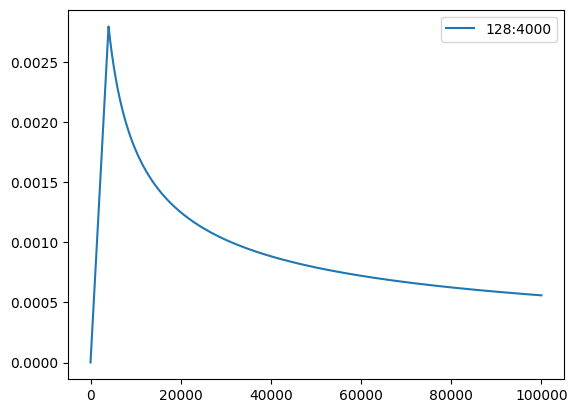

In [34]:
optimizer = NoamOpt(
    model_size=arch_args.encoder_embed_dim, 
    factor=config.lr_factor, 
    warmup=config.lr_warmup, 
    optimizer=torch.optim.AdamW(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9, weight_decay=0.0001))
plt.plot(np.arange(1, 100000), [optimizer.rate(i) for i in range(1, 100000)])
plt.legend([f"{optimizer.model_size}:{optimizer.warmup}"])
None

# 训练步骤

## Training 训练

In [35]:
def move_to_device(obj, device):
    """递归将 tensor 移到 device"""
    if isinstance(obj, torch.Tensor):
        return obj.to(device)
    if isinstance(obj, dict):
        return {k: move_to_device(v, device) for k, v in obj.items()}
    if isinstance(obj, list):
        return [move_to_device(v, device) for v in obj]
    return obj

def grouped_iterator(itr, n):
    """将 iterator 分成 n 个一组"""
    group = []
    for item in itr:
        group.append(item)
        if len(group) == n:
            yield group
            group = []
    if group:
        yield group

def train_one_epoch(train_loader, model, task, criterion, optimizer, accum_steps=1):
    itr = grouped_iterator(train_loader, accum_steps)
    total_steps = (len(train_loader) + accum_steps - 1) // accum_steps
    
    stats = {"loss": []}
    use_amp = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda') if use_amp else None
    
    model.train()
    progress = tqdm(itr, total=total_steps, desc="train", leave=False)
    for samples in progress:
        model.zero_grad()
        accum_loss = 0
        sample_size = 0
        
        for i, sample in enumerate(samples):
            sample = move_to_device(sample, device=device)
            target = sample["target"]
            sample_size_i = sample["ntokens"]
            sample_size += sample_size_i
            
            if use_amp:
                with torch.amp.autocast('cuda'):
                    net_output = model.forward(**sample["net_input"])
                    lprobs = F.log_softmax(net_output[0], -1)            
                    loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1))
                    
                    accum_loss += loss.item()
                    scaler.scale(loss).backward()                
            else:
                net_output = model.forward(**sample["net_input"])
                lprobs = F.log_softmax(net_output[0], -1)
                loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1))
                
                accum_loss += loss.item()
                loss.backward()
        
        if use_amp:
            scaler.unscale_(optimizer)
            optimizer.multiply_grads(1 / (sample_size or 1.0))
            gnorm = nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.multiply_grads(1 / (sample_size or 1.0))
            gnorm = nn.utils.clip_grad_norm_(model.parameters(), config.clip_norm)
            optimizer.step()
        
        loss_print = accum_loss / sample_size
        stats["loss"].append(loss_print)
        progress.set_postfix(loss=loss_print)
        if config.use_wandb:
            wandb.log({
                "train/loss": loss_print,
                "train/grad_norm": gnorm.item(),
                "train/lr": optimizer.rate(),
                "train/sample_size": sample_size,
            })
        
    loss_print = np.mean(stats["loss"])
    logger.info(f"training loss: {loss_print:.4f}")
    return stats

## Validation & Inference 检验和推论
为防止训练发生过度拟合，每过一段时间要做一次检测，计算模型在未看过的资料上的表现。
- 过程基本上和training一样，另外加上 inference
- 检验完毕可顺便储存模型参数

单看 validation loss，我们很难知道模型真实的效能
- 直接用当前模型去生成翻译结果 (hypothesis)，再和正确答案 (reference) 计算 BLEU score
- 也可用肉眼看翻译结果的好坏
- 我们自己实作了 beam search 来生成翻译结果

In [36]:
def strip_pad(tensor, pad_idx):
    """去除 padding tokens"""
    return tensor[tensor != pad_idx]

def beam_search_generate(model, sample, beam_size=5, max_len_a=1.2, max_len_b=10):
    """Beam search 生成翻译"""
    model.eval()
    src_tokens = sample["net_input"]["src_tokens"]
    src_lengths = sample["net_input"]["src_lengths"]
    batch_size = src_tokens.size(0)
    
    # encoder
    encoder_out = model.encoder(src_tokens, src_lengths)
    
    # 初始化 beam
    # beam_tokens: (batch * beam, max_len)
    # beam_scores: (batch, beam)
    pad_idx = task.src_dict.pad()
    eos_idx = task.src_dict.eos()
    
    max_len = int(max_len_a * src_lengths.max().item() + max_len_b)
    
    beam_tokens = torch.full((batch_size * beam_size, max_len + 1), pad_idx, dtype=torch.long, device=device)
    beam_tokens[:, 0] = eos_idx  # 第一个 token 是 eos
    beam_scores = torch.zeros(batch_size, beam_size, device=device)
    beam_scores[:, 1:] = -1e9  # 只有第一个 beam 有初始分数
    
    # 扩展 encoder output 以匹配 beam
    # Transformer 是 batch_first (batch, seq, dim)，RNN 是 seq_first (seq, batch, dim)
    batch_dim = 0 if hasattr(model.encoder, 'pos_encoder') else 1
    encoder_out_expanded = tuple(
        eo.repeat_interleave(beam_size, dim=batch_dim) if eo is not None and eo.dim() > 1 else (eo.repeat_interleave(beam_size) if eo is not None else None)
        for eo in encoder_out
    )
    
    finished = torch.zeros(batch_size, beam_size, dtype=torch.bool, device=device)
    
    for step in range(1, max_len + 1):
        # decoder forward (non-incremental for simplicity)
        prev_tokens = beam_tokens[:, :step]
        logits, _ = model.decoder(prev_tokens, encoder_out_expanded)
        
        # logits: (batch * beam, step, vocab_size)
        # 取最后一个 time step 的 logits
        logits = logits[:, -1, :]  # (batch * beam, vocab_size)
        log_probs = F.log_softmax(logits, dim=-1)
        vocab_size = log_probs.size(-1)
        
        # reshape: (batch, beam, vocab)
        log_probs = log_probs.view(batch_size, beam_size, vocab_size)
        
        # 加上之前的 beam scores
        next_scores = beam_scores.unsqueeze(-1) + log_probs  # (batch, beam, vocab)
        
        # 处理已完成的 beam
        finished_mask = finished.unsqueeze(-1).expand_as(next_scores)
        next_scores.masked_fill_(finished_mask, -1e9)
        
        # 选择 top-k
        next_scores = next_scores.view(batch_size, -1)  # (batch, beam * vocab)
        beam_scores, beam_idx = next_scores.topk(beam_size, dim=-1)
        
        # 计算 beam 和 token
        beam_id = beam_idx // vocab_size  # (batch, beam)
        token_id = beam_idx % vocab_size  # (batch, beam)
        
        # 重排 beam tokens
        new_beam_tokens = beam_tokens.clone()
        for b in range(batch_size):
            for k in range(beam_size):
                src_beam = beam_id[b, k]
                new_beam_tokens[b * beam_size + k, :step] = beam_tokens[b * beam_size + src_beam, :step]
                new_beam_tokens[b * beam_size + k, step] = token_id[b, k]
        beam_tokens = new_beam_tokens
        
        # 检查 eos
        finished = (token_id == eos_idx) | finished
        
        # 如果所有 beam 都完成了，提前结束
        if finished.all():
            break
    
    # 收集结果
    results = []
    for b in range(batch_size):
        hypotheses = []
        for k in range(beam_size):
            tokens = beam_tokens[b * beam_size + k, 1:step + 1]  # 去掉开头的 eos
            # 去掉 eos 之后的 padding
            eos_positions = (tokens == eos_idx).nonzero(as_tuple=True)[0]
            if len(eos_positions) > 0:
                tokens = tokens[:eos_positions[0]]
            hypotheses.append({
                "tokens": tokens.cpu(),
                "score": beam_scores[b, k].item(),
            })
        results.append(hypotheses)
    
    return results

sequence_generator = None  # 不再需要 fairseq 的 generator

def decode(toks, dictionary):
    s = dictionary.string(toks.int().cpu(), config.post_process)
    return s if s else "<unk>"

def inference_step(sample, model):
    gen_out = beam_search_generate(
        model, sample, 
        beam_size=config.beam, 
        max_len_a=config.max_len_a, 
        max_len_b=config.max_len_b
    )
    srcs = []
    hyps = []
    refs = []
    for i in range(len(gen_out)):
        srcs.append(decode(
            strip_pad(sample["net_input"]["src_tokens"][i], task.src_dict.pad()), 
            task.src_dict,
        ))
        hyps.append(decode(
            gen_out[i][0]["tokens"],
            task.tgt_dict,
        ))
        refs.append(decode(
            strip_pad(sample["target"][i], task.tgt_dict.pad()), 
            task.tgt_dict,
        ))
    return srcs, hyps, refs

In [37]:
def validate(model, task, criterion, log_to_wandb=True, skip_bleu=False):
    logger.info('begin validation')
    valid_loader = load_data_iterator(task, "valid", 1, config.max_tokens, config.num_workers)
    
    stats = {"loss":[], "bleu": 0, "srcs":[], "hyps":[], "refs":[]}
    srcs = []
    hyps = []
    refs = []
    
    model.eval()
    progress = tqdm(valid_loader, desc=f"validation", leave=False)
    with torch.no_grad():
        for i, sample in enumerate(progress):
            sample = move_to_device(sample, device=device)
            net_output = model.forward(**sample["net_input"])

            lprobs = F.log_softmax(net_output[0], -1)
            target = sample["target"]
            sample_size = sample["ntokens"]
            loss = criterion(lprobs.view(-1, lprobs.size(-1)), target.view(-1)) / sample_size
            progress.set_postfix(valid_loss=loss.item())
            stats["loss"].append(loss)
            
            if not skip_bleu:
                s, h, r = inference_step(sample, model)
                srcs.extend(s)
                hyps.extend(h)
                refs.extend(r)
            
    stats["loss"] = torch.stack(stats["loss"]).mean().item()
    if not skip_bleu:
        tok = 'zh' if task.tgt_lang == 'zh' else '13a'
        stats["bleu"] = sacrebleu.corpus_bleu(hyps, [refs], tokenize=tok)
    else:
        stats["bleu"] = None
    stats["srcs"] = srcs
    stats["hyps"] = hyps
    stats["refs"] = refs
    
    if config.use_wandb and log_to_wandb:
        log_dict = {"valid/loss": stats["loss"]}
        if stats["bleu"] is not None:
            log_dict["valid/bleu"] = stats["bleu"].score
        wandb.log(log_dict, commit=False)
    
    logger.info(f"validation loss:\t{stats['loss']:.4f}")
    if stats["bleu"] is not None:
        showid = np.random.randint(len(hyps))
        logger.info("example source: " + srcs[showid])
        logger.info("example hypothesis: " + hyps[showid])
        logger.info("example reference: " + refs[showid])
        logger.info(stats["bleu"].format())
    else:
        logger.info("(skip BLEU)")
    return stats

# 储存及载入模型参数

In [38]:
def validate_and_save(model, task, criterion, optimizer, epoch, save=True):   
    skip_bleu = (epoch % config.validate_every != 0)
    stats = validate(model, task, criterion, skip_bleu=skip_bleu)
    bleu = stats['bleu']
    if bleu is None:
        return stats
    loss = stats['loss']
    if save:
        savedir = Path(config.savedir).absolute()
        savedir.mkdir(parents=True, exist_ok=True)
        
        check = {
            "model": model.state_dict(),
            "stats": {"bleu": bleu.score, "loss": loss},
            "optim": {"step": optimizer._step}
        }
        torch.save(check, savedir/f"checkpoint{epoch}.pt")
        shutil.copy(savedir/f"checkpoint{epoch}.pt", savedir/f"checkpoint_last.pt")
        logger.info(f"saved epoch checkpoint: {savedir}/checkpoint{epoch}.pt")
    
        with open(savedir/f"samples{epoch}.{config.source_lang}-{config.target_lang}.txt", "w") as f:
            for s, h in zip(stats["srcs"], stats["hyps"]):
                f.write(f"{s}\t{h}\n")

        if getattr(validate_and_save, "best_bleu", 0) < bleu.score:
            validate_and_save.best_bleu = bleu.score
            torch.save(check, savedir/f"checkpoint_best.pt")
            
        del_file = savedir / f"checkpoint{epoch - config.keep_last_epochs}.pt"
        if del_file.exists():
            del_file.unlink()
    
    return stats

def try_load_checkpoint(model, optimizer=None, name=None):
    name = name if name else "checkpoint_last.pt"
    checkpath = Path(config.savedir)/name
    if checkpath.exists():
        check = torch.load(checkpath)
        model.load_state_dict(check["model"])
        stats = check["stats"]
        step = "unknown"
        if optimizer is not None:
            optimizer._step = step = check["optim"]["step"]
        logger.info(f"loaded checkpoint {checkpath}: step={step} loss={stats['loss']} bleu={stats['bleu']}")
    else:
        logger.info(f"no checkpoints found at {checkpath}!")

# 主程式
## 训练回圈

In [39]:
model = model.to(device=device)
criterion = criterion.to(device=device)

In [40]:
logger.info("task: {}".format(task.__class__.__name__))
logger.info("encoder: {}".format(model.encoder.__class__.__name__))
logger.info("decoder: {}".format(model.decoder.__class__.__name__))
logger.info("criterion: {}".format(criterion.__class__.__name__))
logger.info("optimizer: {}".format(optimizer.__class__.__name__))
logger.info(
    "num. model params: {:,} (num. trained: {:,})".format(
        sum(p.numel() for p in model.parameters()),
        sum(p.numel() for p in model.parameters() if p.requires_grad),
    )
)
logger.info(f"max tokens per batch = {config.max_tokens}, accumulate steps = {config.accum_steps}")

2026-06-21 21:50:44 | INFO | hw5.seq2seq | task: TranslationTask
2026-06-21 21:50:44 | INFO | hw5.seq2seq | encoder: TransformerEncoder
2026-06-21 21:50:44 | INFO | hw5.seq2seq | decoder: TransformerDecoder
2026-06-21 21:50:44 | INFO | hw5.seq2seq | criterion: LabelSmoothedCrossEntropyCriterion
2026-06-21 21:50:44 | INFO | hw5.seq2seq | optimizer: NoamOpt
2026-06-21 21:50:44 | INFO | hw5.seq2seq | num. model params: 2,973,952 (num. trained: 2,973,952)
2026-06-21 21:50:44 | INFO | hw5.seq2seq | max tokens per batch = 1024, accumulate steps = 1


In [ ]:
train_loader = load_data_iterator(task, "train", config.start_epoch, config.max_tokens, config.num_workers)
try_load_checkpoint(model, optimizer, name=config.resume)
for epoch in range(config.start_epoch, config.max_epoch + 1):
    train_one_epoch(train_loader, model, task, criterion, optimizer, config.accum_steps)
    stats = validate_and_save(model, task, criterion, optimizer, epoch=epoch)
    if stats["bleu"] is not None:
        logger.info(f"epoch {epoch}: BLEU={stats['bleu'].score:.2f}")
    else:
        logger.info(f"epoch {epoch}: loss={stats['loss']:.4f} (skip BLEU, next at epoch {epoch + config.validate_every})")


2026-06-21 21:50:44 | INFO | hw5.seq2seq | no checkpoints found at checkpoints/rnn/checkpoint_last.pt!


train:   0%|          | 0/1471 [00:00<?, ?it/s]

2026-06-21 21:52:27 | INFO | hw5.seq2seq | training loss: 7.0794
2026-06-21 21:52:27 | INFO | hw5.seq2seq | begin validation


validation:   0%|          | 0/15 [00:00<?, ?it/s]

2026-06-21 21:52:28 | INFO | hw5.seq2seq | validation loss:	6.4745
2026-06-21 21:52:28 | INFO | hw5.seq2seq | (skip BLEU)
2026-06-21 21:52:28 | INFO | hw5.seq2seq | epoch 1: loss=6.4745 (skip BLEU, next at epoch 4)


...

train:   0%|          | 0/1471 [00:00<?, ?it/s]

2026-06-21 22:18:51 | INFO | hw5.seq2seq | training loss: 4.9064
2026-06-21 22:18:51 | INFO | hw5.seq2seq | begin validation


validation:   0%|          | 0/15 [00:00<?, ?it/s]

2026-06-21 22:18:51 | INFO | hw5.seq2seq | validation loss:	4.8055
2026-06-21 22:18:51 | INFO | hw5.seq2seq | (skip BLEU)
2026-06-21 22:18:51 | INFO | hw5.seq2seq | epoch 20: loss=4.8055 (skip BLEU, next at epoch 23)


train:   0%|          | 0/1471 [00:00<?, ?it/s]

# Submission 缴交档案

In [ ]:
def average_checkpoints(checkdir, num_checkpoints=5):
    """平均最后 N 个 checkpoint"""
    checkdir = Path(checkdir)
    checkpoints = sorted(checkdir.glob("checkpoint*.pt"))
    checkpoints = [c for c in checkpoints if "best" not in c.stem and "last" not in c.stem and "avg" not in c.stem]
    checkpoints = checkpoints[-num_checkpoints:]
    
    if len(checkpoints) == 0:
        logger.warning("No checkpoints to average!")
        return
    
    logger.info(f"Averaging {len(checkpoints)} checkpoints: {[c.name for c in checkpoints]}")
    
    avg_state = None
    for ckpt in checkpoints:
        state = torch.load(ckpt)
        if avg_state is None:
            avg_state = deepcopy(state)
        else:
            for k in avg_state["model"]:
                avg_state["model"][k] += state["model"][k]
    
    for k in avg_state["model"]:
        avg_state["model"][k] /= len(checkpoints)
    
    output_path = checkdir / "avg_last_5_checkpoint.pt"
    torch.save(avg_state, output_path)
    logger.info(f"Saved averaged checkpoint: {output_path}")

checkdir = config.savedir
average_checkpoints(checkdir, num_checkpoints=5)

## 确认生成缴交档案的模型参数

In [ ]:
# checkpoint_last.pt : 最后一次检验的档案
# checkpoint_best.pt : 检验 BLEU 最高的档案
# avg_last_5_checkpoint.pt:　最5后个档案平均
try_load_checkpoint(model, name="avg_last_5_checkpoint.pt")
validate(model, task, criterion, log_to_wandb=False)
None

## 进行预测

In [ ]:
def generate_prediction(model, task, split="test", outfile="./prediction.txt"):    
    task.load_dataset(split=split)
    pred_loader = load_data_iterator(task, split, 1, config.max_tokens, config.num_workers)
    
    idxs = []
    hyps = []

    model.eval()
    progress = tqdm(pred_loader, desc=f"prediction")
    with torch.no_grad():
        for i, sample in enumerate(progress):
            sample = move_to_device(sample, device=device)
            s, h, r = inference_step(sample, model)
            hyps.extend(h)
            idxs.extend(sample['id'])
            
    hyps = [x for _,x in sorted(zip(idxs,hyps))]
    
    with open(outfile, "w") as f:
        for h in hyps:
            f.write(h+"\n")

In [ ]:
generate_prediction(model, task)

In [ ]:
raise

# Back-translation

## 训练一个反向的翻译模型

1. 将实验的参数设定表中(config)的source_lang与target_lang互相交换
2. 将实验的参数设定表中(config)的savedir更改(ex. "./checkpoints/rnn-back")
3. 训练一个反向模型

## 利用反向模型生成额外资料

### 下载 monolingual data

In [ ]:
mono_dataset_name = 'mono'

In [ ]:
mono_prefix = Path(data_dir).absolute() / mono_dataset_name
mono_prefix.mkdir(parents=True, exist_ok=True)

urls = (
    '"https://onedrive.live.com/download?cid=3E549F3B24B238B4&resid=3E549F3B24B238B4%214986&authkey=AANUKbGfZx0kM80"',
# # If the above links die, use the following instead. 
#     "https://www.csie.ntu.edu.tw/~r09922057/ML2021-hw5/ted_zh_corpus.deduped.gz",
# # If the above links die, use the following instead. 
#     "https://mega.nz/#!vMNnDShR!4eHDxzlpzIpdpeQTD-htatU_C7QwcBTwGDaSeBqH534",
)
file_names = (
    'ted_zh_corpus.deduped.gz',
)

for u, f in zip(urls, file_names):
    path = mono_prefix/f
    if not path.exists():
        if 'mega' in u:
            !megadl {u} --path {path}
        else:
            !wget {u} -O {path}
    else:
        print(f'{f} is exist, skip downloading')
    if path.suffix == ".tgz":
        !tar -xvf {path} -C {prefix}
    elif path.suffix == ".zip":
        !unzip -o {path} -d {prefix}
    elif path.suffix == ".gz":
        !gzip -fkd {path}

### TODO: 清理资料集

1. 将太长、太短的句子移除
2. 统一标点符号

hint: 可以使用clean_s()来协助

### TODO: Subword Units

用反向模型的 spm model 将资料切成 subword units

hint: spm model 的路径为 DATA/raw-data/\[dataset\]/spm\[vocab_num\].model

### Binarize

使用fairseq将资料转为binary

In [ ]:
binpath = Path('./DATA/data-bin', mono_dataset_name)
src_dict_file = './DATA/data-bin/ted2020/dict.en.txt'
tgt_dict_file = src_dict_file
monopref = str(mono_prefix/"mono.tok") # whatever filepath you get after applying subword tokenization
if binpath.exists():
    print(binpath, "exists, will not overwrite!")
else:
    !python -m fairseq_cli.preprocess\
        --source-lang 'zh'\
        --target-lang 'en'\
        --trainpref {monopref}\
        --destdir {binpath}\
        --srcdict {src_dict_file}\
        --tgtdict {tgt_dict_file}\
        --workers 2

### TODO: 生成反向翻译资料

将 binarized data 加入原本的资料夹中并用一个 split_name 取名

ex. ./DATA/data-bin/ted2020/\[split_name\].zh-en.\["en", "zh"\].\["bin", "idx"\]

便可以使用 generate_prediction(model, task, split="split_name")来产生翻译资料

In [ ]:
# 将 binarized data 加入原本的资料夹中并用一个 split_name 取名
# ex. ./DATA/data-bin/ted2020/\[split_name\].zh-en.\["en", "zh"\].\["bin", "idx"\]
!cp ./DATA/data-bin/mono/train.zh-en.zh.bin ./DATA/data-bin/ted2020/mono.zh-en.zh.bin
!cp ./DATA/data-bin/mono/train.zh-en.zh.idx ./DATA/data-bin/ted2020/mono.zh-en.zh.idx
!cp ./DATA/data-bin/mono/train.zh-en.en.bin ./DATA/data-bin/ted2020/mono.zh-en.en.bin
!cp ./DATA/data-bin/mono/train.zh-en.en.idx ./DATA/data-bin/ted2020/mono.zh-en.en.idx

In [ ]:
# hint: 用反向模型在 split='mono' 上进行预测，生成 prediction_file
# generate_prediction( ... ,split=... ,outfile=... )

### TODO: 产生新的dataset

1. 将翻译出来的资料与原先的训练资料结合
2. 使用之前的spm model切出成Subword Units
3. 重新使用fairseq将资料转为binary

In [ ]:
# 合并刚刚生成的 prediction_file (.en) 以及中文 mono.zh (.zh)
# 
# hint: 在此用刚刚的 spm model 对 prediction_file 进行切断词
# spm_model.encode(line, out_type=str)
# output: ./DATA/rawdata/mono/mono.tok.en & mono.tok.zh
#
# hint: 在此用 fairseq 把这些档案再 binarize
# binpath = Path('./DATA/data-bin/synthetic')
# src_dict_file = './DATA/data-bin/ted2020/dict.en.txt'
# tgt_dict_file = src_dict_file
# monopref = ./DATA/rawdata/mono/mono.tok # or whatever path after applying subword tokenization, w/o the suffix (.zh/.en)
# if binpath.exists():
#     print(binpath, "exists, will not overwrite!")
# else:
#     !python -m fairseq_cli.preprocess\
#         --source-lang 'zh'\
#         --target-lang 'en'\
#         --trainpref {monopref}\
#         --destdir {binpath}\
#         --srcdict {src_dict_file}\
#         --tgtdict {tgt_dict_file}\
#         --workers 2

In [ ]:
# 这里用刚刚准备的档案合并原先 ted2020 来生成最终 back-translation 的资料
!cp -r ./DATA/data-bin/ted2020/ ./DATA/data-bin/ted2020_with_mono/

!cp ./DATA/data-bin/synthetic/train.zh-en.zh.bin ./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.bin
!cp ./DATA/data-bin/synthetic/train.zh-en.zh.idx ./DATA/data-bin/ted2020_with_mono/train1.en-zh.zh.idx
!cp ./DATA/data-bin/synthetic/train.zh-en.en.bin ./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.bin
!cp ./DATA/data-bin/synthetic/train.zh-en.en.idx ./DATA/data-bin/ted2020_with_mono/train1.en-zh.en.idx

### TODO: 重新训练

当已经产生新的资料集

1. 将实验的参数设定表(config)中的datadir改为新的资料集("./DATA/data-bin/ted2020_with_mono")
2. 将实验的参数设定表(config)中的source_lang与target_lang设定还原("en", "zh")
3. 将实验的参数设定表(config)中的savedir更改(ex. "./checkpoints/rnn-bt")
4. 重新训练

# References

1. <a name=ott2019fairseq></a>Ott, M., Edunov, S., Baevski, A., Fan, A., Gross, S., Ng, N., ... & Auli, M. (2019, June). fairseq: A Fast, Extensible Toolkit for Sequence Modeling. In Proceedings of the 2019 Conference of the North American Chapter of the Association for Computational Linguistics (Demonstrations) (pp. 48-53).
2. <a name=vaswani2017></a>Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017, December). Attention is all you need. In Proceedings of the 31st International Conference on Neural Information Processing Systems (pp. 6000-6010).
3. <a name=reimers-2020-multilingual-sentence-bert></a>Reimers, N., & Gurevych, I. (2020, November). Making Monolingual Sentence Embeddings Multilingual Using Knowledge Distillation. In Proceedings of the 2020 Conference on Empirical Methods in Natural Language Processing (EMNLP) (pp. 4512-4525).
4. <a name=tiedemann2012parallel></a>Tiedemann, J. (2012, May). Parallel Data, Tools and Interfaces in OPUS. In Lrec (Vol. 2012, pp. 2214-2218).
5. <a name=kudo-richardson-2018-sentencepiece></a>Kudo, T., & Richardson, J. (2018, November). SentencePiece: A simple and language independent subword tokenizer and detokenizer for Neural Text Processing. In Proceedings of the 2018 Conference on Empirical Methods in Natural Language Processing: System Demonstrations (pp. 66-71).
6. <a name=sennrich-etal-2016-improving></a>Sennrich, R., Haddow, B., & Birch, A. (2016, August). Improving Neural Machine Translation Models with Monolingual Data. In Proceedings of the 54th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers) (pp. 86-96).
7. <a name=edunov-etal-2018-understanding></a>Edunov, S., Ott, M., Auli, M., & Grangier, D. (2018). Understanding Back-Translation at Scale. In Proceedings of the 2018 Conference on Empirical Methods in Natural Language Processing (pp. 489-500).
8. https://github.com/ajinkyakulkarni14/TED-Multilingual-Parallel-Corpus
9. https://ithelp.ithome.com.tw/articles/10233122
10. https://nlp.seas.harvard.edu/2018/04/03/attention.html